In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2025-12-19 16:57:02.562417: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-19 16:57:02.563418: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 16:57:02.566362: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 16:57:02.574255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766163422.587470   20709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766163422.59

In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.12.0


In [3]:
# train/validation = 80/20
dataset = pd.read_csv('dataset/ngtdm/kernel5-radius5/dataset.csv')
train_data, validation_data = train_test_split(
    dataset, test_size=0.2, random_state=42
)

In [4]:
# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label"
)

E0000 00:00:1766163424.461635   20709 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1766163424.462153   20709 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
import keras

In [6]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpy4_utjd0 as temporary training directory
Reading training dataset...
Training dataset read in 0:00:05.762803. Found 89956 examples.
Training model...


I0000 00:00:1766163430.342836   20709 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1766163430.342891   20709 kernel.cc:783] Collect training examples
I0000 00:00:1766163430.342899   20709 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1766163430.343108   20709 kernel.cc:401] Number of batches: 90
I0000 00:00:1766163430.343117   20709 kernel.cc:402] Number of examples: 89956
I0000 00:00:1766163430.345163   20709 kernel.cc:802] Training dataset:
Number of records: 89956
Number of columns: 6

Number of columns by type:
	NUMERICAL: 5 (83.3333%)
	CATEGORICAL: 1 (16.6667%)

Columns:

NUMERICAL: 5 (83.3333%)
	0: "Busyness" NUMERICAL m

Model trained in 0:00:08.236073
Compiling model...


I0000 00:00:1766163438.431648   20709 decision_forest.cc:808] Model loaded with 300 root(s), 789644 node(s), and 5 input feature(s).
I0000 00:00:1766163438.434915   20709 abstract_model.cc:1439] Engine "RandomForestOptPred" built
2025-12-19 16:57:18.434983: I tensorflow_decision_forests/tensorflow/ops/inference/kernel.cc:1035] Use fast generic engine


Model compiled.
CPU times: user 1min 28s, sys: 1.66 s, total: 1min 30s
Wall time: 14.7 s


In [7]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

23/23 [==============================] - 1s 28ms/step - loss: 0.0000e+00 - accuracy: 0.9567

loss: 0.0000
accuracy: 0.9567


In [8]:
# Model Summary
model.summary()

Model: "random_forest_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (5):
	Busyness
	Coarseness
	Complexity
	Contrast
	Strength

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.   "Busyness"  0.841807 ################
    2. "Coarseness"  0.334433 ####
    3. "Complexity"  0.182050 #
    4.   "Contrast"  0.145224 
    5.   "Strength"  0.125881 

Variable Importance: NUM_AS_ROOT:
    1.   "Busyness" 255.000000 ################
    2. "Coarseness" 45.000000 

Variable Importance: NUM_NODES:
    1.   "Busyness" 88843.000000 ################
    2.   "Strength" 80236.000000 ########
    3. "Complexity" 78057.000000 ######
    4.   "Contrast" 77096.000000 

In [9]:
# Model features
model.make_inspector().features()

["Busyness" (1; #0),
 "Coarseness" (1; #1),
 "Complexity" (1; #2),
 "Contrast" (1; #3),
 "Strength" (1; #4)]

In [10]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Busyness" (1; #0), 0.8418067147950204),
  ("Coarseness" (1; #1), 0.33443297182766324),
  ("Complexity" (1; #2), 0.1820497038124311),
  ("Contrast" (1; #3), 0.14522352870703464),
  ("Strength" (1; #4), 0.12588139682405503)],
 'NUM_AS_ROOT': [("Busyness" (1; #0), 255.0), ("Coarseness" (1; #1), 45.0)],
 'SUM_SCORE': [("Busyness" (1; #0), 2194847.4519466227),
  ("Coarseness" (1; #1), 1318274.835258699),
  ("Complexity" (1; #2), 679985.8694416058),
  ("Strength" (1; #4), 652144.35825588),
  ("Contrast" (1; #3), 535762.0391080483)],
 'NUM_NODES': [("Busyness" (1; #0), 88843.0),
  ("Strength" (1; #4), 80236.0),
  ("Complexity" (1; #2), 78057.0),
  ("Contrast" (1; #3), 77096.0),
  ("Coarseness" (1; #1), 70440.0)]}

In [11]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=89956, accuracy=0.9582462537240428, loss=0.29618564894746796, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

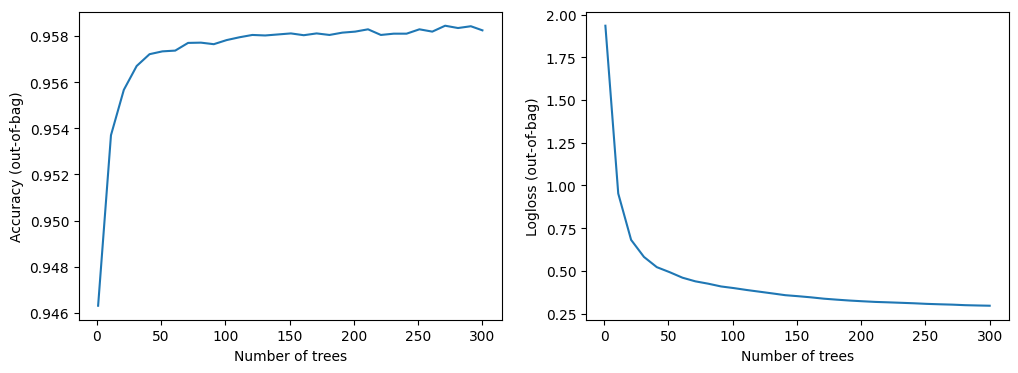

In [12]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [13]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

23/23 [==============================] - 1s 29ms/step
The ROC AUC score is 0.93281


In [14]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(val_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = validation_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

23/23 [==============================] - 1s 28ms/step
Sklearn binary metrics:
accuracy: 0.9567
precision: 0.8165
recall: 0.5256
f1: 0.6395
mcc: 0.6346
roc_auc: 0.9328
pr_auc: 0.7349
log_loss: 0.1627
brier_score: 0.0335

Confusion matrix:
 [[20654   194]
 [  779   863]]

Classification report:
               precision    recall  f1-score   support

           0     0.9637    0.9907    0.9770     20848
           1     0.8165    0.5256    0.6395      1642

    accuracy                         0.9567     22490
   macro avg     0.8901    0.7581    0.8082     22490
weighted avg     0.9529    0.9567    0.9523     22490

